# Análisis Exploratorio de Datos (EDA) – Turismo en España

**Primera Entrega** : Aprendizaje Automático

El objetivo es realizar un análisis exploratorio de datos (EDA) sobre información turística de España, combinando:

- Datos de viajeros/pernoctaciones por provincia (EOH – Encuesta de Ocupación Hotelera)

## 2. Origen de los datoss 


Se utiliza una fuente oficial INE:

- EOH (Encuesta de Ocupación Hotelera). Datos mensuales de viajeros y pernoctaciones por provincia. 

El dataset se descargó en formato CSV desde fuentes oficiales (INE / Datos.gob.es).


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import re
import warnings

from catboost import CatBoostRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
from itertools import product

In [2]:
ruta_eoh = "../dataset/per.csv"    

df_turismo = pd.read_csv(ruta_eoh, sep=';', low_memory=False)

### Preparación de datos

- Renombramos columnas para que tengan nombres sencillos
- Creamos variables temporales (año, mes, temporada)


In [3]:
df_turismo.head()

,Totales Territoriales,Comunidades y Ciudades Autónomas,Provincias,Viajeros y pernoctaciones,Residencia: Nivel 1,Residencia: Nivel 2,Periodo,Total
0,Total Nacional,NaN,NaN,Viajero,Total,NaN,2025M09,12.050.972
1,Total Nacional,NaN,NaN,Viajero,Total,NaN,2025M08,13.828.672
2,Total Nacional,NaN,NaN,Viajero,Total,NaN,2025M07,13.044.764
3,Total Nacional,NaN,NaN,Viajero,Total,NaN,2025M06,12.256.716
4,Total Nacional,NaN,NaN,Viajero,Total,NaN,2025M05,11.803.477


In [4]:
df_turismo.columns

Index(['Totales Territoriales', 'Comunidades y Ciudades Autónomas',
       'Provincias', 'Viajeros y pernoctaciones', 'Residencia: Nivel 1',
       'Residencia: Nivel 2', 'Periodo', 'Total'],
      dtype='object')

La columna "Residencia: Nivel 1" contiene únicamente el elemento "Total". Por lo que se elimina del dataset.

In [5]:
df_turismo["Residencia: Nivel 1"].unique()

array(['Total'], dtype=object)

In [6]:
df_turismo = df_turismo.drop(columns=["Residencia: Nivel 1"])

La columna "Residencia: Nivel 2" contiene "Residentes en España" y "Residentes en el extranjero". Debido al objetivo del proyecto se utilizarán únicamente "Residentes en el Extranjero". Por lo que, también se elimina la columna "Residencia: Nivel 2", ya que todos sus valores se corresponden a "Residentes en el Extranjero" y no aporta ningún valor.

In [7]:
df_turismo["Residencia: Nivel 2"].unique()

array([nan, 'Residentes en España', 'Residentes en el Extranjero'],
      dtype=object)

In [8]:
df_turismo = df_turismo[df_turismo["Residencia: Nivel 2"] == "Residentes en el Extranjero"]

In [9]:
df_turismo.drop(columns=["Residencia: Nivel 2"], inplace=True)

La columna "Totales Territoriales" contiene unicamente "Total Nacional".

In [10]:
df_turismo["Totales Territoriales"].unique()

array(['Total Nacional'], dtype=object)

Se renombran las columnas.

In [11]:
df_turismo.columns

Index(['Totales Territoriales', 'Comunidades y Ciudades Autónomas',
       'Provincias', 'Viajeros y pernoctaciones', 'Periodo', 'Total'],
      dtype='object')

In [12]:
df_turismo = df_turismo.rename(columns={
    "Totales Territoriales" : "Total_nacional",
    "Comunidades y Ciudades Autónomas" : "Comunidades_ciudades_autonomas",
    "Viajeros y pernoctaciones" : "Tipo_turista",
    "Total" : "Turistas_totales"  
})

La columna "Periodo" se divide en dos columnas "Año" y "Mes" para facilitar el análisis posterior. Además, se crea la columna "Temporada" para clasificar los meses en periodos temporales.

In [13]:

def temporada(mes):
    if mes in [6, 7, 8]:
        return 'Verano'
    elif mes in [12, 1, 2]:
        return 'Invierno'
    elif mes in [3, 4, 5]:
        return 'Primavera'
    else:
        return 'Otoño'


In [14]:
df_turismo['Año'] = df_turismo['Periodo'].str[:4].astype(int)
df_turismo['Mes'] = df_turismo['Periodo'].str[-2:].astype(int)
df_turismo['Temporada'] = df_turismo['Mes'].apply(temporada)

In [15]:
df_turismo.head(5)

,Total_nacional,Comunidades_ciudades_autonomas,Provincias,Tipo_turista,Periodo,Turistas_totales,Año,Mes,Temporada
642,Total Nacional,NaN,NaN,Viajero,2025M09,6.965.279,2025,9,Otoño
643,Total Nacional,NaN,NaN,Viajero,2025M08,7.419.417,2025,8,Verano
644,Total Nacional,NaN,NaN,Viajero,2025M07,7.202.305,2025,7,Verano
645,Total Nacional,NaN,NaN,Viajero,2025M06,6.816.343,2025,6,Verano
646,Total Nacional,NaN,NaN,Viajero,2025M05,6.870.352,2025,5,Primavera


Se elimina la columna "Periodo".

In [16]:
df_turismo = df_turismo.drop(columns=["Periodo"])

## Corrección de nombres.

Se modifican los nombres de las Comunidades y ciudades autónomas y de las provincias para mayor claridad.

In [17]:
def correccion_nombres(n):

    if pd.isna(n):
        return n
    
    n= re.sub(r"^\d+\s", "", n)

    if ", " in n:
        a = n.split(", ")
        n = " ".join(a[::-1])
    
    n = re.sub(r"^(La|El|Los|Las|de)(\S)", r"\1 \2", n)

    n = re.sub(r"\b(La) s\b", "Las", n)

    n = n.strip()

    return n


df_turismo["Comunidades_ciudades_autonomas"] = df_turismo["Comunidades_ciudades_autonomas"].apply(correccion_nombres)
df_turismo["Provincias"] = df_turismo["Provincias"].apply(correccion_nombres)

In [18]:
df_turismo["Comunidades_ciudades_autonomas"].unique()

array([nan, 'Andalucía', 'Aragón', 'Principado de Asturias',
       'Illes Balears', 'Canarias', 'Cantabria', 'Castilla y León',
       'Castilla - La Mancha', 'Cataluña', 'Comunitat Valenciana',
       'Extremadura', 'Galicia', 'Comunidad de Madrid',
       'Región de Murcia', 'Comunidad Foral de Navarra', 'País Vasco',
       'La Rioja', 'Ceuta', 'Melilla'], dtype=object)

In [19]:
df_turismo["Provincias"].unique()

array([nan, 'Almería', 'Cádiz', 'Córdoba', 'Granada', 'Huelva', 'Jaén',
       'Málaga', 'Sevilla', 'Huesca', 'Teruel', 'Zaragoza', 'Asturias',
       'Illes Balears', 'Las Palmas', 'Santa Cruz de Tenerife',
       'Cantabria', 'Ávila', 'Burgos', 'León', 'Palencia', 'Salamanca',
       'Segovia', 'Soria', 'Valladolid', 'Zamora', 'Albacete',
       'Ciudad Real', 'Cuenca', 'Guadalajara', 'Toledo', 'Barcelona',
       'Girona', 'Lleida', 'Tarragona', 'Alicante/Alacant',
       'Castellón/Castelló', 'Valencia/València', 'Badajoz', 'Cáceres',
       'A Coruña', 'Lugo', 'Ourense', 'Pontevedra', 'Madrid', 'Murcia',
       'Navarra', 'Araba/Álava', 'Bizkaia', 'Gipuzkoa', 'La Rioja'],
      dtype=object)

## Comprobación duplicados

Se añade una columna "ID" en formato hash para generar un identificador único para cada fila para facilitar la posible detección de duplicados.

In [20]:
df_turismo["ID"] = df_turismo.apply(lambda row: hash(tuple(row)), axis=1)

In [21]:
orden_columnas = ["ID"] + [c for c in df_turismo.columns if c != "ID"]
df_turismo = df_turismo[orden_columnas]

In [22]:
df_turismo.head(1)

,ID,Total_nacional,Comunidades_ciudades_autonomas,Provincias,Tipo_turista,Turistas_totales,Año,Mes,Temporada
642,3262211622262590899,Total Nacional,NaN,NaN,Viajero,6.965.279,2025,9,Otoño


In [23]:
df_turismo["ID"].value_counts()[df_turismo["ID"].value_counts()>1]

Series([], Name: count, dtype: int64)

In [24]:
df_turismo.duplicated().sum()

np.int64(0)

## Análisis de tipos de datos

Se comprueban los tipos de datos. Se convierte la columna "Turistas_totales" a float y las columnas "Año" y "Mes" a int.

In [25]:
df_turismo.dtypes

ID                                 int64
Total_nacional                    object
Comunidades_ciudades_autonomas    object
Provincias                        object
Tipo_turista                      object
Turistas_totales                  object
Año                                int64
Mes                                int64
Temporada                         object
dtype: object

In [26]:
df_turismo['Turistas_totales'] = (
    df_turismo['Turistas_totales']
    .astype(str)
    .str.replace('.', '', regex=False)
    .str.replace(',', '.', regex=False)
)

df_turismo['Turistas_totales'] = pd.to_numeric(df_turismo['Turistas_totales'], errors='coerce')


In [27]:
df_turismo["Turistas_totales"] = df_turismo["Turistas_totales"].astype(float)
df_turismo["Año"] = df_turismo["Año"].astype(int)
df_turismo["Mes"] = df_turismo["Mes"].astype(int)

In [28]:
df_turismo.dtypes

ID                                  int64
Total_nacional                     object
Comunidades_ciudades_autonomas     object
Provincias                         object
Tipo_turista                       object
Turistas_totales                  float64
Año                                 int64
Mes                                 int64
Temporada                          object
dtype: object

## Detección de errores o inconsistencias

In [29]:
df_turismo.isnull().sum().sort_values(ascending=False)

Provincias                        12840
Comunidades_ciudades_autonomas      642
Turistas_totales                     29
ID                                    0
Total_nacional                        0
Tipo_turista                          0
Año                                   0
Mes                                   0
Temporada                             0
dtype: int64

In [30]:
df_turismo[df_turismo["Comunidades_ciudades_autonomas"].isna()].head(1)

,ID,Total_nacional,Comunidades_ciudades_autonomas,Provincias,Tipo_turista,Turistas_totales,Año,Mes,Temporada
642,3262211622262590899,Total Nacional,NaN,NaN,Viajero,6965279.0,2025,9,Otoño


In [31]:
df_turismo[df_turismo["Provincias"].isna()].head(1)

,ID,Total_nacional,Comunidades_ciudades_autonomas,Provincias,Tipo_turista,Turistas_totales,Año,Mes,Temporada
642,3262211622262590899,Total Nacional,NaN,NaN,Viajero,6965279.0,2025,9,Otoño


In [32]:
df_turismo[df_turismo["Turistas_totales"].isna()].head(1)

,ID,Total_nacional,Comunidades_ciudades_autonomas,Provincias,Tipo_turista,Turistas_totales,Año,Mes,Temporada
8379,7570058845727201147,Total Nacional,Andalucía,Córdoba,Viajero,NaN,2022,12,Invierno


Se detecta que las ciudades autónomas de Ceuta y Mellina no se indican en la columna provincia por lo que aparecen como Nan. Estas dos ciudades se indican en la columna "Comunidades_ciudades_autonomas". Por lo cual, se han sustuído estos valores nulos por su identifiactivo en de la columna "Comunidades_ciudades_autonomas".

In [33]:
'Ceuta' in df_turismo['Provincias'].values
'Melilla' in df_turismo['Provincias'].values

False

In [34]:
ciudades_autonomas = df_turismo['Comunidades_ciudades_autonomas'].str.contains("Ceuta|Melilla", case=False, na=False)
df_turismo.loc[ciudades_autonomas, 'Provincias'] = df_turismo.loc[ciudades_autonomas, 'Comunidades_ciudades_autonomas'].str.extract('(Ceuta|Melilla)', expand=False)

In [35]:
'Ceuta' in df_turismo['Provincias'].values
'Melilla' in df_turismo['Provincias'].values

True

## Falta explicar

In [36]:
df_turismo["Año"].nunique()

27

In [37]:
año = 2024

comprobacion = df_turismo[
    (df_turismo["Año"] == año) &
    (df_turismo["Comunidades_ciudades_autonomas"].isna()) &
    (df_turismo["Provincias"].isna())
]

comprobacion.head(5)

,ID,Total_nacional,Comunidades_ciudades_autonomas,Provincias,Tipo_turista,Turistas_totales,Año,Mes,Temporada
651,-5768627148828744866,Total Nacional,NaN,NaN,Viajero,2916057.0,2024,12,Invierno
652,-3449833857129481591,Total Nacional,NaN,NaN,Viajero,3397063.0,2024,11,Otoño
653,2977002618828682138,Total Nacional,NaN,NaN,Viajero,6233770.0,2024,10,Otoño
654,-5510440063777639273,Total Nacional,NaN,NaN,Viajero,6762248.0,2024,9,Otoño
655,-5030740855746343800,Total Nacional,NaN,NaN,Viajero,7259558.0,2024,8,Verano


In [38]:
comprobacion_2 = (
    df_turismo["Comunidades_ciudades_autonomas"].isna() &
    df_turismo["Provincias"].isna()
)

comprobacion_2.sum()

np.int64(642)

In [39]:
total_nacional = df_turismo["Comunidades_ciudades_autonomas"].isna() & df_turismo["Provincias"].isna()

df_turismo.loc[
    (df_turismo["Comunidades_ciudades_autonomas"].notna()) |
    (df_turismo["Provincias"].notna()),
    "Total_nacional"
] = "No aplica"

In [40]:
df_turismo["Total_nacional"].value_counts()

Total_nacional
No aplica         44298
Total Nacional      642
Name: count, dtype: int64

In [41]:
df_turismo.head(2)

,ID,Total_nacional,Comunidades_ciudades_autonomas,Provincias,Tipo_turista,Turistas_totales,Año,Mes,Temporada
642,3262211622262590899,Total Nacional,NaN,NaN,Viajero,6965279.0,2025,9,Otoño
643,-624359018387672039,Total Nacional,NaN,NaN,Viajero,7419417.0,2025,8,Verano


In [42]:
df_turismo.loc[df_turismo["Total_nacional"] == "Total Nacional",
               ["Comunidades_ciudades_autonomas", "Provincias"]] = "No aplica"

In [43]:
comprobacion_provincias = df_turismo["Provincias"].isna() & df_turismo["Comunidades_ciudades_autonomas"].notna()
comprobacion_provincias.sum()

np.int64(10914)

In [44]:
df_turismo["Provincias"] = df_turismo["Provincias"].fillna("No aplica")

In [45]:
df_turismo[df_turismo["Turistas_totales"].isna()]

,ID,Total_nacional,Comunidades_ciudades_autonomas,Provincias,Tipo_turista,Turistas_totales,Año,Mes,Temporada
8379,7570058845727201147,No aplica,Andalucía,Córdoba,Viajero,NaN,2022,12,Invierno
46929,-1154450696815731493,No aplica,Castilla y León,Ávila,Viajero,NaN,2020,6,Verano
46930,4072644344681623333,No aplica,Castilla y León,Ávila,Viajero,NaN,2020,5,Primavera
47892,-2865166420197745783,No aplica,Castilla y León,Ávila,Pernoctaciones,NaN,2020,6,Verano
47893,4021514076597334496,No aplica,Castilla y León,Ávila,Pernoctaciones,NaN,2020,5,Primavera
50781,-3903565739281689210,No aplica,Castilla y León,León,Viajero,NaN,2020,6,Verano
50782,-2362816490203545195,No aplica,Castilla y León,León,Viajero,NaN,2020,5,Primavera
51744,-5566006088657211184,No aplica,Castilla y León,León,Pernoctaciones,NaN,2020,6,Verano
51745,-2693039024755612595,No aplica,Castilla y León,León,Pernoctaciones,NaN,2020,5,Primavera
52707,-5347266536283204962,No aplica,Castilla y León,Palencia,Viajero,NaN,2020,6,Verano


In [46]:
df_turismo = df_turismo.dropna(subset=["Turistas_totales"])

In [47]:
df_turismo["Turistas_totales"].isnull().sum()

np.int64(0)

Se comprueba si quedan valores nulos.

In [48]:
df_turismo.isnull().sum().sort_values(ascending=False)

ID                                0
Total_nacional                    0
Comunidades_ciudades_autonomas    0
Provincias                        0
Tipo_turista                      0
Turistas_totales                  0
Año                               0
Mes                               0
Temporada                         0
dtype: int64

## Comprobación de duplicados.

Se vuelve a comprobar, mediante su "ID", si durante el proceso de limpieza se ha generado erróneamente algun duplicado.

In [49]:
df_turismo["ID"].value_counts()[df_turismo["ID"].value_counts()>1]

Series([], Name: count, dtype: int64)

## Tratamiento de outliers

Se comprueba si hay valores nulos. Inicialmente se comprueba si el z-score de "Turistas_totales" de cada provincia es superior o inferior a más de tres desviaciones estandar de la media. Posteriormente, en las filas que se han detectado outliers, se compara el valor de turistas_totales con la media de turistas_totales de su misma comunidad o ciudad autónoma en el mismo año y mes. Las filas detectadas se eliminan para no distorsionar el posterior análisis. 

In [50]:
df_turismo["Outliers_zscore"] = df_turismo.groupby("Provincias", observed=False)["Turistas_totales"].transform(
    lambda x: np.abs((x - x.mean()) / x.std()) > 3)

df_turismo["Outliers_zscore"].sum()

np.int64(554)

In [51]:
df_turismo[df_turismo["Outliers_zscore"]][["Provincias", "Turistas_totales", "Año", "Mes"]].head(10)

,Provincias,Turistas_totales,Año,Mes
1605,No aplica,27517185.0,2025,9
1606,No aplica,30962964.0,2025,8
1607,No aplica,29796067.0,2025,7
1608,No aplica,26790929.0,2025,6
1609,No aplica,24674795.0,2025,5
1610,No aplica,19028107.0,2025,4
1611,No aplica,14328386.0,2025,3
1612,No aplica,11845120.0,2025,2
1613,No aplica,11175213.0,2025,1
1614,No aplica,10818842.0,2024,12


In [52]:
outliers_zscore_2 = df_turismo["Outliers_zscore"]

media_comunidad_ciudad = df_turismo.groupby(["Comunidades_ciudades_autonomas", "Año", "Mes"])["Turistas_totales"].transform("mean")
std = df_turismo.groupby(["Comunidades_ciudades_autonomas", "Año", "Mes"])["Turistas_totales"].transform("std")

outl = np.abs(df_turismo["Turistas_totales"] - media_comunidad_ciudad) / std > 3

outliers = df_turismo[outliers_zscore_2 & outl]

total_verificacion_outliers = (outliers_zscore_2 & outl).sum()

total_verificacion_outliers


np.int64(0)

In [53]:
outliers[["Provincias", "Turistas_totales", "Año", "Mes"]]

,Provincias,Turistas_totales,Año,Mes


In [54]:
outliers_3 = outliers_zscore_2 & outl
df_turismo.drop(df_turismo[outliers_3].index, inplace=True)

In [55]:
comprobacion = (df_turismo["Outliers_zscore"] & outl).sum()
comprobacion

np.int64(0)

## Analisis Exploratorio 

Se excluyen las filas correspondientes a los valores "No aplica" en las columnas "Comunidades_ciudades_autonomas" y "Provincias" para analizar posteriormente el total de turistas por provincias o comunidades/ciudades autónomas.

In [56]:
df_territorial = df_turismo[
    (df_turismo["Comunidades_ciudades_autonomas"] != "No aplica") &
    (df_turismo["Provincias"] != "No aplica")
].copy()

### Análisis  univariante

Analizamos la distribución de "Turistas_totales".


In [57]:
df_territorial[['Turistas_totales']].describe()


,Turistas_totales
count,3.335500e+04
mean,1.673101e+05
std,6.195267e+05
min,0.000000e+00
25%,5.021500e+03
50%,1.597800e+04
75%,6.518350e+04
max,1.053256e+07


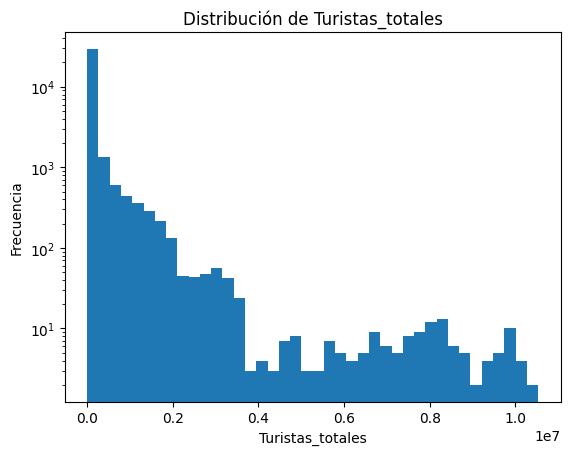

In [58]:
plt.figure()

df_territorial['Turistas_totales'].plot(kind="hist", bins=40, log=True)
plt.title("Distribución de Turistas_totales")
plt.xlabel("Turistas_totales")
plt.ylabel("Frecuencia")
plt.show()

### Análisis por provincia y temporada

Queremos saber:

- Qué provincias reciben más turismo en verano
- Qué provincias destacan en invierno
- Cómo se distribuyen los turistas por temporadas

In [59]:
df_temporada = (
    df_territorial
    .groupby(['Provincias', 'Temporada'], as_index=False, observed=True)
    .agg({'Turistas_totales': 'sum'})
)

df_temporada.head()


,Provincias,Temporada,Turistas_totales
0,A Coruña,Invierno,2939542.0
1,A Coruña,Otoño,10075256.0
2,A Coruña,Primavera,8528653.0
3,A Coruña,Verano,13166327.0
4,Albacete,Invierno,391921.0


In [60]:
df_temporada_suma = df_territorial.groupby("Temporada", observed=False)["Turistas_totales"].sum().reset_index()
df_temporada_suma = df_temporada_suma.sort_values(by="Turistas_totales", ascending=False)
df_temporada_suma.head()

,Temporada,Turistas_totales
3,Verano,2.094021e+09
1,Otoño,1.453468e+09
2,Primavera,1.290812e+09
0,Invierno,7.423263e+08


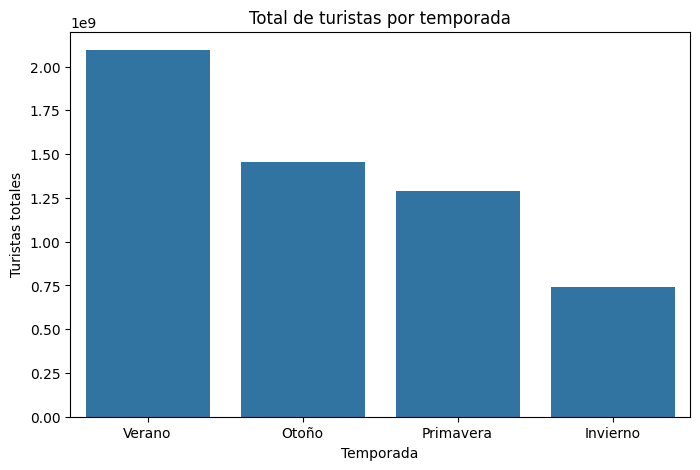

In [61]:
plt.figure(figsize=(8,5))
sns.barplot(x="Temporada", y="Turistas_totales", data=df_temporada_suma, order=df_temporada_suma["Temporada"])
plt.title("Total de turistas por temporada")
plt.ylabel("Turistas totales")
plt.xlabel("Temporada")
plt.show()

Top provincias en verano.

In [62]:
top_verano = (
    df_temporada[df_temporada['Temporada'] == 'Verano']
    .sort_values('Turistas_totales', ascending=False)
    .head(10)
)
top_verano.head()

,Provincias,Temporada,Turistas_totales
99,Illes Balears,Verano,745528291.0
31,Barcelona,Verano,235237221.0
111,Las Palmas,Verano,202545899.0
79,Girona,Verano,127616989.0
163,Santa Cruz de Tenerife,Verano,127271218.0


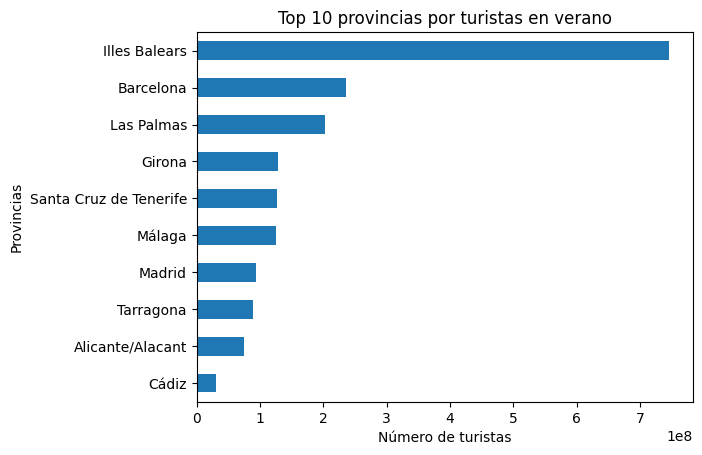

In [63]:
top_verano.plot(kind='barh', x='Provincias', y='Turistas_totales', legend=False)
plt.gca().invert_yaxis()
plt.title("Top 10 provincias por turistas en verano")
plt.xlabel("Número de turistas")
plt.ylabel("Provincias")
plt.show()

Top provincias en invierno.

In [64]:
top_invierno = (
    df_temporada[df_temporada['Temporada'] == 'Invierno']
    .sort_values('Turistas_totales', ascending=False)
    .head(10)
)
top_invierno

,Provincias,Temporada,Turistas_totales
108,Las Palmas,Invierno,196998986.0
160,Santa Cruz de Tenerife,Invierno,141689196.0
28,Barcelona,Invierno,92158304.0
124,Madrid,Invierno,68724397.0
136,Málaga,Invierno,47555289.0
8,Alicante/Alacant,Invierno,40854427.0
96,Illes Balears,Invierno,33715342.0
168,Sevilla,Invierno,17640347.0
188,Valencia/València,Invierno,13801275.0
80,Granada,Invierno,13204112.0


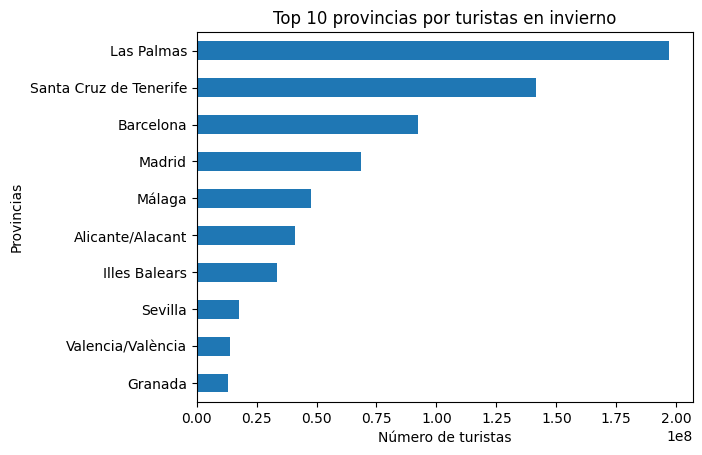

In [65]:
top_invierno.plot(kind='barh', x='Provincias', y='Turistas_totales', legend=False)
plt.gca().invert_yaxis()
plt.title("Top 10 provincias por turistas en invierno")
plt.xlabel("Número de turistas")
plt.ylabel("Provincias")
plt.show()

### Análisis por Comunidades y ciudades autónomas por temporada.

In [66]:
df_temporada_comunidades = (
    df_territorial
    .groupby(['Comunidades_ciudades_autonomas', 'Temporada'], as_index=False, observed=False)
    .agg({'Turistas_totales': 'sum'})
)

df_temporada_comunidades.head()

,Comunidades_ciudades_autonomas,Temporada,Turistas_totales
0,Andalucía,Invierno,97091272.0
1,Andalucía,Otoño,202569099.0
2,Andalucía,Primavera,202718139.0
3,Andalucía,Verano,240783228.0
4,Aragón,Invierno,4723426.0


Top Comunidades y ciudades autónomas en verano.

In [67]:
top_verano_comunidades = (
    df_temporada_comunidades[df_temporada_comunidades['Temporada'] == 'Verano']
    .sort_values('Turistas_totales', ascending=False)
    .head(10)
)
top_verano_comunidades

,Comunidades_ciudades_autonomas,Temporada,Turistas_totales
55,Illes Balears,Verano,745528291.0
27,Cataluña,Verano,454288518.0
11,Canarias,Verano,329817117.0
3,Andalucía,Verano,240783228.0
43,Comunitat Valenciana,Verano,107334128.0
39,Comunidad de Madrid,Verano,94029175.0
67,País Vasco,Verano,25822762.0
51,Galicia,Verano,24683588.0
23,Castilla y León,Verano,21269323.0
7,Aragón,Verano,11163816.0


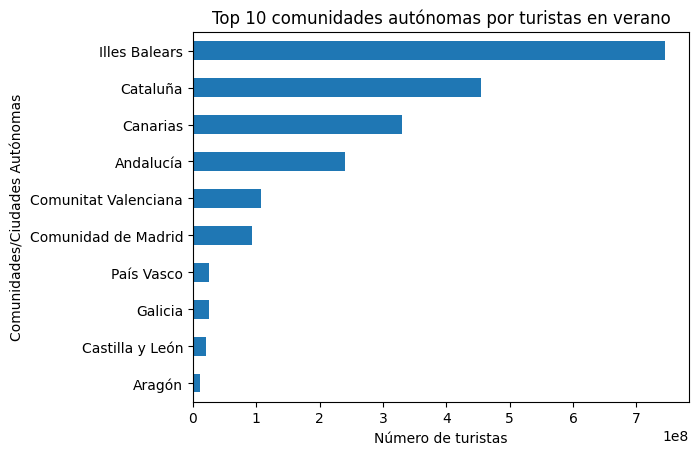

In [68]:
top_verano_comunidades.plot(kind='barh', x='Comunidades_ciudades_autonomas', y='Turistas_totales', legend=False)
plt.gca().invert_yaxis()
plt.title("Top 10 comunidades autónomas por turistas en verano")
plt.xlabel("Número de turistas")
plt.ylabel("Comunidades/Ciudades Autónomas")
plt.show()

Top Comunidades y Ciudades Autónomas en invierno.

In [69]:
top_invierno_comunidades = (
    df_temporada_comunidades[df_temporada_comunidades['Temporada'] == 'Invierno']
    .sort_values('Turistas_totales', ascending=False)
    .head(10)
)
top_invierno_comunidades

,Comunidades_ciudades_autonomas,Temporada,Turistas_totales
8,Canarias,Invierno,338688182.0
24,Cataluña,Invierno,107349632.0
0,Andalucía,Invierno,97091272.0
36,Comunidad de Madrid,Invierno,68724397.0
40,Comunitat Valenciana,Invierno,56654364.0
52,Illes Balears,Invierno,33715342.0
64,País Vasco,Invierno,8698538.0
20,Castilla y León,Invierno,6811840.0
48,Galicia,Invierno,5835033.0
4,Aragón,Invierno,4723426.0


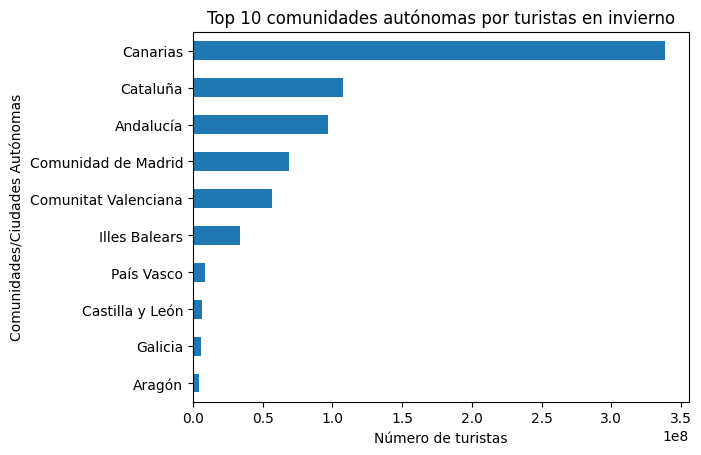

In [70]:
top_invierno_comunidades.plot(kind='barh', x='Comunidades_ciudades_autonomas', y='Turistas_totales', legend=False)
plt.gca().invert_yaxis()
plt.title("Top 10 comunidades autónomas por turistas en invierno")
plt.xlabel("Número de turistas")
plt.ylabel("Comunidades/Ciudades Autónomas")
plt.show()

In [71]:
df_territorial.to_csv("CSVs/df_turismo_limpio.csv", index=False)